# Transfer-test reward rate per curriculum step

Plots reward rate (y) against curriculum step number (x) for the `transfer_test_gru_*` runs.

- **Groups / colors:** `transfer_test_gru_exp_fixed*` (one color) vs `transfer_test_gru_markov_randomized*` (another). One line per network in each group.
- **Per-step summary:** each curriculum step (`_reward_rates/step_XX/`) is reduced to the mean reward rate over its **last up-to-`LAST_K` sessions**. For `step_00` (long training stage) this is the converged reward rate; for the short eval stages it is the mean over their sessions.
- **Session file:** each file stores a `(100,)` array of per-update mean rewards; a session's reward rate is that array's mean. A few files were written by more than one run (append mode); we use the most recent array.

In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_checkpoints() -> Path:
    """Locate the repo's checkpoints/ dir by walking up from the cwd."""
    here = Path.cwd()
    for cand in [here, *here.parents]:
        c = cand / 'checkpoints'
        if c.is_dir():
            return c
    raise FileNotFoundError('Could not find a checkpoints/ directory above cwd')


CKPT = find_checkpoints()
LAST_K = 50  # summarize each step by the mean over its last up-to-K sessions

# Make the shared plotting helper (repo_root/code/aux_funcs.py) importable.
sys.path.insert(0, str(CKPT.parent / 'code'))
from aux_funcs import format_plot

# Use Helvetica for all text.
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica'] + plt.rcParams['font.sans-serif']

# group name -> (glob pattern, color). exp_indep is intentionally excluded.
GROUPS = {
    'V1':         ('transfer_test_gru_exp_fixed*',         'tab:blue'),
    'Randomized Markov': ('transfer_test_gru_markov_randomized*', 'tab:red'),
    'Randomized V1': ('transfer_test_gru_exp_indep*', 'tab:green'),
}

# Which curriculum steps to plot, and the test-environment label for each.
# step_00 (the training stage) is excluded.
STEP_LABELS = {1: 'Randomized\nMarkov', 2: 'V1', 3: 'Randomized\nV1'}

print('checkpoints dir:', CKPT)

checkpoints dir: /home/david.bell/work/favorably_connected_2/checkpoints


In [2]:
def load_session_means(step_dir: Path) -> list[float]:
    """Per-session mean reward for a curriculum step, in session order.

    Each session file holds one (or, if a dir was written by multiple runs,
    several) appended (100,) arrays of per-update mean rewards. We take the
    last array (most recent run) and average it to one reward rate.
    """
    means = []
    for f in sorted(p for p in step_dir.iterdir() if p.is_file()):
        arrs = []
        with open(f, 'rb') as fh:
            while True:
                try:
                    arrs.append(np.load(fh))
                except Exception:
                    break
        if arrs:
            means.append(float(np.mean(arrs[-1])))
    return means


def step_summary(step_dir: Path, last_k: int = LAST_K) -> float:
    """Converged reward rate for a step = mean over its last up-to-last_k sessions."""
    means = load_session_means(step_dir)
    return float(np.mean(means[-last_k:])) if means else np.nan


def run_step_summaries(run_dir: Path):
    """Return (step_numbers, reward_rates) across a run's curriculum steps."""
    xs, ys = [], []
    for st in sorted((run_dir / '_reward_rates').glob('step_*')):
        m = re.search(r'step_(\d+)', st.name)
        if m is None:
            continue
        xs.append(int(m.group(1)))
        ys.append(step_summary(st))
    return xs, ys

In [3]:
# Gather per-run, per-step summaries.
data = {}  # group -> list of (run_name, xs, ys)
for gname, (pattern, _color) in GROUPS.items():
    runs = sorted(CKPT.glob(pattern))
    data[gname] = [(r.name, *run_step_summaries(r)) for r in runs]

for gname, runs in data.items():
    print(f'\n{gname}:')
    for name, xs, ys in runs:
        print(f'  {name}: ' + ', '.join(f'step{ x}={y:.4f}' for x, y in zip(xs, ys)))


V1:
  transfer_test_gru_exp_fixed_net0: step0=0.0594, step1=0.0102, step2=0.0673, step3=0.0492
  transfer_test_gru_exp_fixed_net1: step0=0.0667, step1=0.0073, step2=0.0674, step3=0.0470

Randomized Markov:
  transfer_test_gru_markov_randomized_long_train: step0=0.0312, step1=0.0313, step2=0.0545, step3=0.0563
  transfer_test_gru_markov_randomized_net0: step0=0.0305, step1=0.0308, step2=0.0571, step3=0.0601
  transfer_test_gru_markov_randomized_net1: step0=0.0308, step1=0.0305, step2=0.0558, step3=0.0604

Randomized V1:
  transfer_test_gru_exp_indep_net0: step0=0.0594, step1=0.0306, step2=0.0583, step3=0.0612
  transfer_test_gru_exp_indep_net1: step0=0.0593, step1=0.0291, step2=0.0574, step3=0.0616
  transfer_test_gru_exp_indep_tau_capped_40_net0: step0=0.0523, step1=0.0296, step2=0.0581, step3=0.0613
  transfer_test_gru_exp_indep_tau_capped_40_net1: step0=0.0522, step1=0.0289, step2=0.0583, step3=0.0620


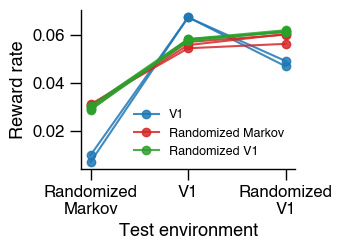

In [4]:
fig, ax = plt.subplots(figsize=(3.5, 2.6))

steps = sorted(STEP_LABELS)  # curriculum steps to show (step_00 excluded)
for gname, (pattern, color) in GROUPS.items():
    labeled = False
    for name, xs, ys in data[gname]:
        lookup = dict(zip(xs, ys))
        yv = [lookup.get(s, np.nan) for s in steps]
        ax.plot(steps, yv, marker='o', color=color, alpha=0.85,
                label=(None if labeled else gname))
        labeled = True

ax.set_xlabel('Test environment')
ax.set_ylabel('Reward rate')
ax.set_xticks(steps)
ax.set_xticklabels([STEP_LABELS[s] for s in steps])
ax.legend(frameon=False, loc='lower right', fontsize=9)
format_plot(ax)
fig.tight_layout()
plt.show()

## Stop-fraction plots (step_02)

For every network in the reward-rate plot above, load the `step_02` odor-site dataframe from `results/<run>/step_02/traj_*.pkl` and make `plot_stop_fraction` heatmaps for `patch_type == 1` and `patch_type == 2` — same settings as `behavioral_gru_offset_indep_offsets_and_decays`.

In [5]:
import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import jax
import seaborn as sns

jax.config.update('jax_platforms', 'cpu')

plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import (
    plot_session,
    load_odor_site_df,
    plot_patch_statistics_per_session,
    plot_patch_statistics_across_dfs,
    plot_patch_statistics,
    plot_multi_df_accuracy_heatmap,
    plot_leave_probabilities,
    plot_stay_prob_distance_difference,
    append_index_phase,
    plot_grouped_mean_std,
    plot_stop_fraction,
    plot_first_patch_rewards_vs_other_prefactors,
    plot_rewards_by_patch_sequence,
    odor_colors,
)
from aux_funcs import format_plot, zero_pad
from nb_analysis_tools import *

In [6]:
# Load step_02 odor-site dataframes for every network in the reward-rate plot above.
RESULTS = CKPT.parent / 'results'
STEP_FOR_STOP_FRACTION = 'step_02'

# (group, run_name, trajectory_path) per network with a step_02 trajectory,
# in the same order/grouping as the reward-rate plot. Networks lacking a
# step_02 rollout (e.g. an incomplete run) are skipped.
step02_networks = []
for gname, (pattern, _color) in GROUPS.items():
    for run_dir in sorted(RESULTS.glob(pattern)):
        trajs = sorted((run_dir / STEP_FOR_STOP_FRACTION).glob('traj_*.pkl'))
        if not trajs:
            print(f'  skipping {run_dir.name}: no {STEP_FOR_STOP_FRACTION} trajectory')
            continue
        step02_networks.append((gname, run_dir.name, trajs[-1]))

stop_fraction_dfs = []
for nn_num, (gname, run_name, traj_path) in enumerate(step02_networks):
    print(f'Loading {run_name}  <-  {traj_path.name}')
    stop_fraction_dfs.append(load_odor_site_df(str(traj_path), nn_num=nn_num))

Loading transfer_test_gru_exp_fixed_net0  <-  traj_001002.pkl
Session data loaded
Session summaries generated
Loading transfer_test_gru_exp_fixed_net1  <-  traj_001002.pkl
Session data loaded
Session summaries generated
Loading transfer_test_gru_markov_randomized_long_train  <-  traj_000004.pkl
Session data loaded
Session summaries generated
Loading transfer_test_gru_markov_randomized_net0  <-  traj_001002.pkl
Session data loaded
Session summaries generated
Loading transfer_test_gru_markov_randomized_net1  <-  traj_001002.pkl
Session data loaded
Session summaries generated
Loading transfer_test_gru_exp_indep_net0  <-  traj_001002.pkl
Session data loaded
Session summaries generated
Loading transfer_test_gru_exp_indep_net1  <-  traj_001002.pkl
Session data loaded
Session summaries generated
Loading transfer_test_gru_exp_indep_tau_capped_40_net0  <-  traj_001002.pkl
Session data loaded
Session summaries generated
Loading transfer_test_gru_exp_indep_tau_capped_40_net1  <-  traj_001002.pkl


transfer_test_gru_exp_fixed_net0  |  patch_type == 1


ValueError: too many values to unpack (expected 3)

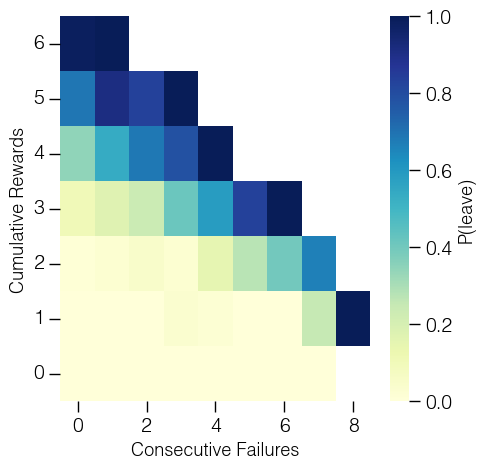

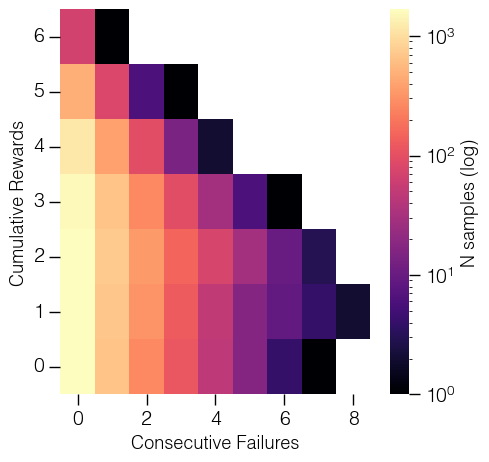

In [7]:
# Two stop_fraction plots per network: patch_type == 1 and patch_type == 2.
# Same settings as behavioral_gru_offset_indep_offsets_and_decays.
MIN_N = 1  # min samples per (x, y) cell; lower if a step_02 df has little data

for (gname, run_name, _traj), df in zip(step02_networks, stop_fraction_dfs):
    for patch_type in (1, 2):
        print(f'{run_name}  |  patch_type == {patch_type}')
        fig, ax, matrix = plot_stop_fraction(
            df,
            'consecutive_misses',
            'rewards_seen_in_patch',
            invert_y=True,
            condition=lambda x, pt=patch_type: x[x['patch_type'] == pt],
            figsize=(5, 5),
            reverse=True,
            xlabel='Consecutive Failures',
            ylabel='Cumulative Rewards',
            min_n=MIN_N,
            vmin=0, vmax=1,
        )
        ax.set_xlim(-0.5, 10.5)
        ax.set_ylim(-0.5, 30)